In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

df = pd.read_csv('/kaggle/input/datasets/chiagoziemichael/mobile/Mobile.csv')

X = df.drop('price_range', axis=1)
y = df['price_range']

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30]
}

print("Starting Grid Search...")
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, scoring='accuracy')
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
print(f"Best Hyperparameters: {grid_search.best_params_}")

Starting Grid Search...
Best Hyperparameters: {'max_depth': 30, 'n_estimators': 200}


In [2]:
cv_scores = cross_val_score(best_rf, X, y, cv=5)
print(f"Cross-Validation Accuracy Scores: {cv_scores}")
print(f"Average CV Accuracy: {cv_scores.mean():.4f}")

y_pred = best_rf.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Cross-Validation Accuracy Scores: [0.2575 0.25   0.3075 0.2875 0.26  ]
Average CV Accuracy: 0.2725

Classification Report:
                precision    recall  f1-score   support

     High cost       0.24      0.29      0.26        92
      Low cost       0.34      0.25      0.29       105
   Medium cost       0.21      0.34      0.26        91
Very High cost       0.39      0.22      0.28       112

      accuracy                           0.27       400
     macro avg       0.29      0.28      0.27       400
  weighted avg       0.30      0.27      0.27       400



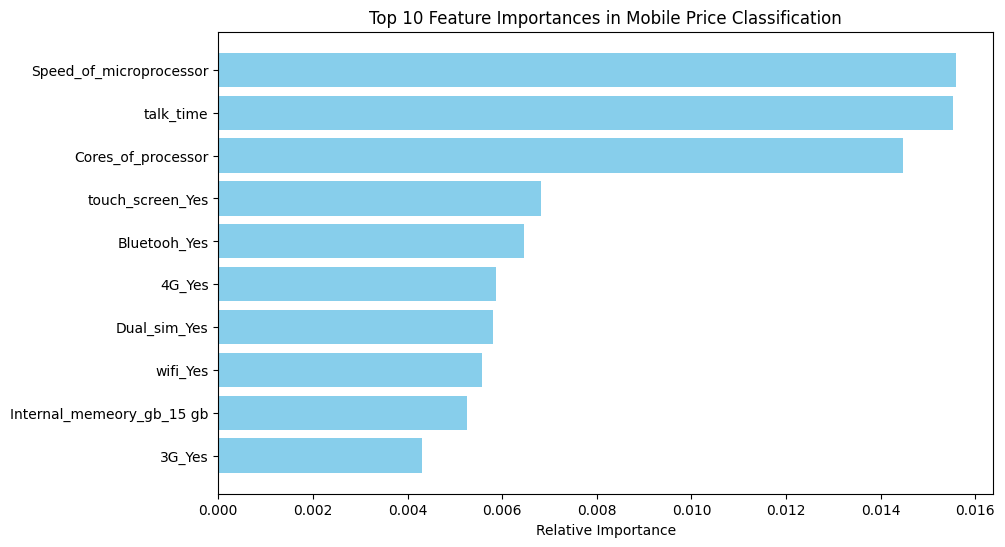

In [3]:
importances = best_rf.feature_importances_

feature_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_df['Feature'][:10], feature_df['Importance'][:10], color='skyblue')
plt.gca().invert_yaxis()  # Put the most important feature at the top
plt.title('Top 10 Feature Importances in Mobile Price Classification')
plt.xlabel('Relative Importance')
plt.show()